# Vou comparar os dados obitidos para diferentes temperatuas

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [67]:
plt.style.use('/home/joliveira/Documents/franck-hertz/joao.mplstyle')
# --- DEFINIÇÃO DO TEMA GLOBAL USANDO rcParams ---
plt.rcParams['figure.figsize'] = (20, 12) # Define o tamanho da figura para 10x6 polegadas
plt.rcParams['font.size'] = 14           # Define o tamanho da fonte geral como 14
plt.rcParams['axes.titlesize'] = 25      # Tamanho da fonte do título
plt.rcParams['axes.labelsize'] = 20      # Tamanho da fonte dos rótulos dos eixos
plt.rcParams['axes.grid'] = True        # Habilita/desabilita a grade em todos os gráficos
plt.rcParams['grid.linestyle'] = '-'      # Estilo da grade: tracejado
plt.rcParams['grid.alpha'] = 0.6         # Transparência da grade
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['savefig.dpi'] = 700        # Alta resolução para salvar as figuras
plt.rcParams['lines.linestyle'] = '-'    # Linha sólida
plt.rcParams['lines.linewidth'] = 3   # Espessura da linha
plt.rcParams['figure.facecolor'] = 'none'   # Fundo da figura transparente
plt.rcParams['axes.facecolor']   = 'none'   # Fundo dos eixos transparente
plt.rcParams['savefig.facecolor'] = 'none'  # Ao salvar, mantém transparente
plt.rcParams['savefig.transparent'] = True  # Salva figuras com fundo transparente
plt.rcParams['xtick.labelsize'] = 16    # Tamanho dos rótulos do eixo x
plt.rcParams['ytick.labelsize'] = 16    # Tamanho dos rótulos do eixo y
# ---------------------------------------------------

Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 617 ('view raw')
Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 618 ('matplotlibrc hosted with ❤ by GitHub')


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.signal import find_peaks

def plot_medida_temperatura(
    pasta_dados,
    pasta_excel,
    medida,
    temperatura,
    limite_potencial=30,
    log=True,
    mostrar_marcadores=True
):
    """
    Plota a curva de uma medida (m1, m2, ...) em uma única temperatura,
    aplicando o fator de escala obtido do arquivo Excel correspondente.

    Parâmetros:
    - pasta_dados: pasta onde estão os arquivos .txt das medidas
    - pasta_excel: pasta onde estão os arquivos Excel com fator de escala
    - medida: número inteiro (1 a 12)
    - temperatura: número inteiro (ex: 130, 140, 150, 160)
    - limite_potencial: valor máximo de potencial a ser exibido no gráfico
    - log: se True, o eixo y será logarítmico (default=True)
    - mostrar_marcadores: se True, mostra os marcadores nos mínimos (default=True)
    """

    marcador = "o"

    # --- Caminhos dos arquivos ---
    nome_excel = f"Medidas Multiplas Excitações {temperatura}°C (Com fator de escala).xlsx"
    caminho_excel = os.path.join(pasta_excel, nome_excel)
    nome_txt = f"m{medida}-m-e-T_{temperatura}.txt"
    caminho_txt = os.path.join(pasta_dados, nome_txt)

    # --- Verificações ---
    if not os.path.exists(caminho_excel):
        print(f"[Erro] Arquivo Excel não encontrado: {caminho_excel}")
        return
    if not os.path.exists(caminho_txt):
        print(f"[Erro] Arquivo de dados não encontrado: {caminho_txt}")
        return

    # --- Lê fator de escala ---
    df_info = pd.read_excel(caminho_excel)
    linha = df_info.loc[df_info["Medida"] == medida]
    if linha.empty:
        print(f"[Erro] Medida {medida} não encontrada em {nome_excel}")
        return

    escala = linha["Escala "].values[0]

    # --- Lê dados experimentais ---
    df = pd.read_csv(
        caminho_txt,
        sep=r"\s+",
        header=None,
        names=["Potencial (V)", "Corrente (uA)"]
    )

    # --- Aplica fator de escala ---
    df["Corrente (uA)"] *= escala
    df = df[df["Potencial (V)"] <= limite_potencial].reset_index(drop=True)

    V = df["Potencial (V)"].to_numpy()
    I = df["Corrente (uA)"].to_numpy()

    # --- Suavização simples ---
    I_suave = np.convolve(I, np.ones(5)/5, mode='same')

    # --- Encontra vales ---
    dist = int(3 * max(20, len(V)//50) * 1.75)
    prom = 0.05 * (I.max() - I.min())
    vales, _ = find_peaks(-I_suave, distance=dist, prominence=prom)

    # --- Cria figura e plota ---
    fig, ax = plt.subplots()

    ax.plot(
        V, I,
        label=f"{temperatura}°C",
        marker=marcador,
        markevery=50,
        linewidth=1.8
    )

    # --- Marca vales (se solicitado) ---
    if mostrar_marcadores and len(vales) > 0:
        ax.scatter(
            V[vales], I[vales],
            color="#d1052a",
            edgecolor="black",
            s=100,
            linewidth=1.2,
            zorder=5,
            marker="X"
        )

    # --- Configurações visuais ---
    ax.set_xlabel("Potencial (V)")
    ax.set_ylabel("Corrente (uA)")
    ax.set_title(f"Medida {medida} — {temperatura}°C")

    if log:
        ax.set_yscale("log")

    ax.grid(True, which='both', linestyle='--', linewidth=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()


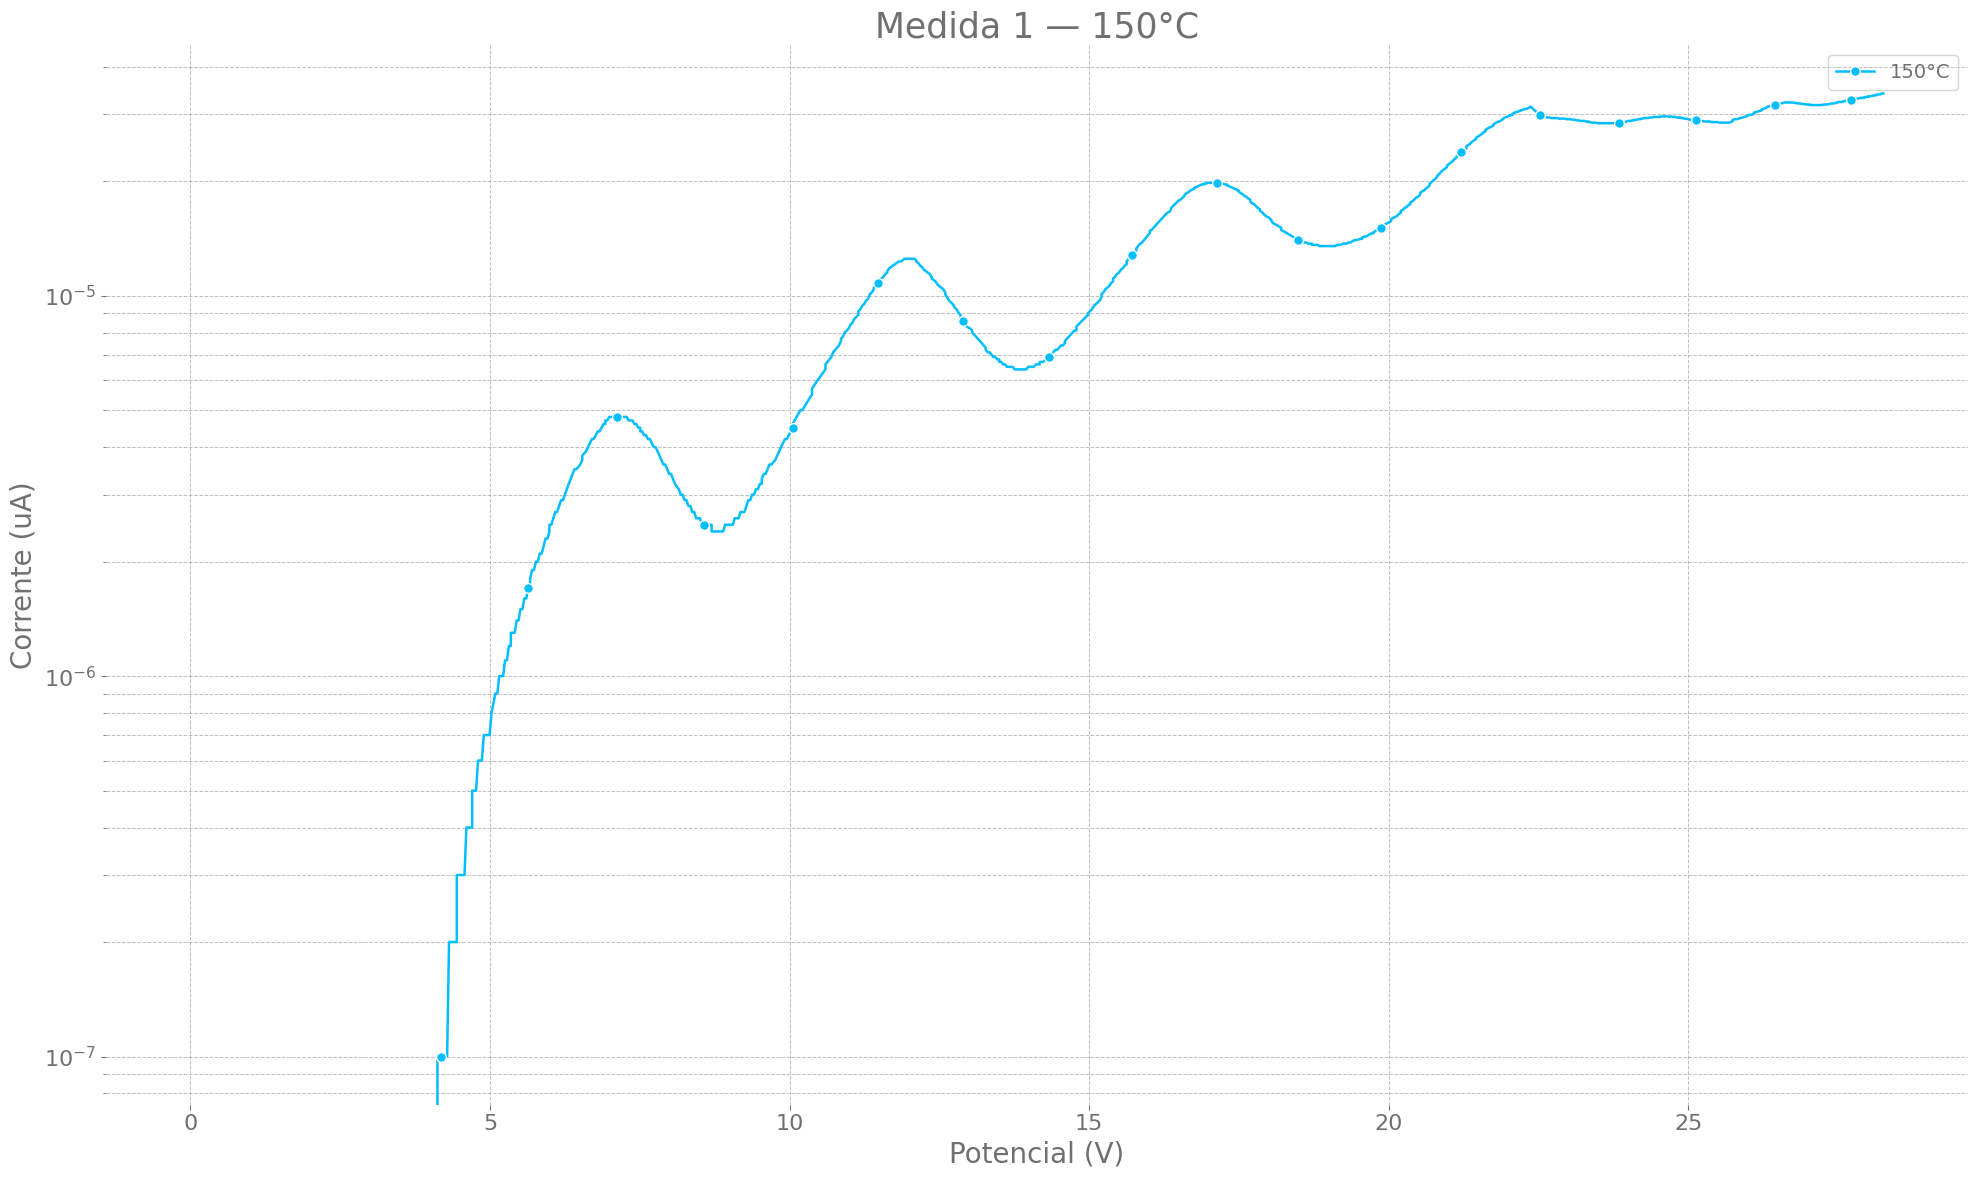

In [69]:
plot_medida_temperatura(
    pasta_dados="Dados experimentais 23.10.2025 (Com fator de escala)/",
    pasta_excel="/home/joliveira/Documents/franck-hertz/",
    medida=1,
    temperatura=150,
    log=True,
    mostrar_marcadores=False
)


In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.signal import find_peaks

def plot_multiplas_temperaturas(
    pasta_dados,
    pasta_excel,
    medida,
    temperaturas=(130, 140, 150, 160),
    limite_potencial=30,
    log=True,
    mostrar_marcadores=True
):
    """
    Plota em um único gráfico as curvas de uma mesma medida (m1, m2, ...)
    em várias temperaturas, aplicando o fator de escala de cada Excel correspondente.

    Parâmetros:
    - pasta_dados: pasta onde estão os arquivos .txt das medidas
    - pasta_excel: pasta onde estão os arquivos Excel com fator de escala
    - medida: número inteiro (1 a 12)
    - temperaturas: lista ou tupla com as temperaturas desejadas
    - limite_potencial: valor máximo de potencial exibido no gráfico
    - log: se True, o eixo y será logarítmico (default=True)
    - mostrar_marcadores: se True, mostra marcadores nos mínimos (default=True)
    """

    marcador = "o"
    fig, ax = plt.subplots()

    for temperatura in temperaturas:
        # --- Caminhos dos arquivos ---
        nome_excel = f"Medidas Multiplas Excitações {temperatura}°C (Com fator de escala).xlsx"
        caminho_excel = os.path.join(pasta_excel, nome_excel)
        nome_txt = f"m{medida}-m-e-T_{temperatura}.txt"
        caminho_txt = os.path.join(pasta_dados, nome_txt)

        # --- Verificações ---
        if not os.path.exists(caminho_excel):
            print(f"[Aviso] Excel não encontrado: {caminho_excel}")
            continue
        if not os.path.exists(caminho_txt):
            print(f"[Aviso] Dados não encontrados: {caminho_txt}")
            continue

        # --- Lê fator de escala ---
        df_info = pd.read_excel(caminho_excel)
        linha = df_info.loc[df_info["Medida"] == medida]
        if linha.empty:
            print(f"[Aviso] Medida {medida} não encontrada em {nome_excel}")
            continue

        escala = linha["Escala "].values[0]

        # --- Lê dados experimentais ---
        df = pd.read_csv(
            caminho_txt,
            sep=r"\s+",
            header=None,
            names=["Potencial (V)", "Corrente (A)"]
        )

        # --- Aplica fator de escala ---
        df["Corrente (A)"] *= escala
        df = df[df["Potencial (V)"] <= limite_potencial].reset_index(drop=True)

        V = df["Potencial (V)"].to_numpy()
        I = df["Corrente (A)"].to_numpy()

        # --- Suavização simples ---
        I_suave = np.convolve(I, np.ones(5)/5, mode='same')

        # --- Encontra vales ---
        dist = int(3 * max(20, len(V)//50) * 1.75)
        prom = 0.05 * (I.max() - I.min())
        vales, _ = find_peaks(-I_suave, distance=dist, prominence=prom)

        # --- Plota linha ---
        ax.plot(
            V, I,
            label=f"{temperatura}°C",
            marker=marcador,
            markevery=50,
            linewidth=1.8
        )

        # --- Marca vales (se solicitado) ---
        if mostrar_marcadores and len(vales) > 0:
            ax.scatter(
                V[vales], I[vales],
                color="#d1052a",
                edgecolor="black",
                s=100,
                linewidth=1.2,
                zorder=5,
                marker="X"
            )

    # --- Configurações visuais ---
    ax.set_xlabel("Potencial (V)")
    ax.set_ylabel("Corrente (A)")
    ax.set_title(f"Medida {medida}— Temperaturas múltiplas")

    if log:
        ax.set_yscale("log")

    ax.grid(True, which='both', linestyle='--', linewidth=0.7)
    ax.legend(title="Temperatura")
    plt.tight_layout()
    plt.show()


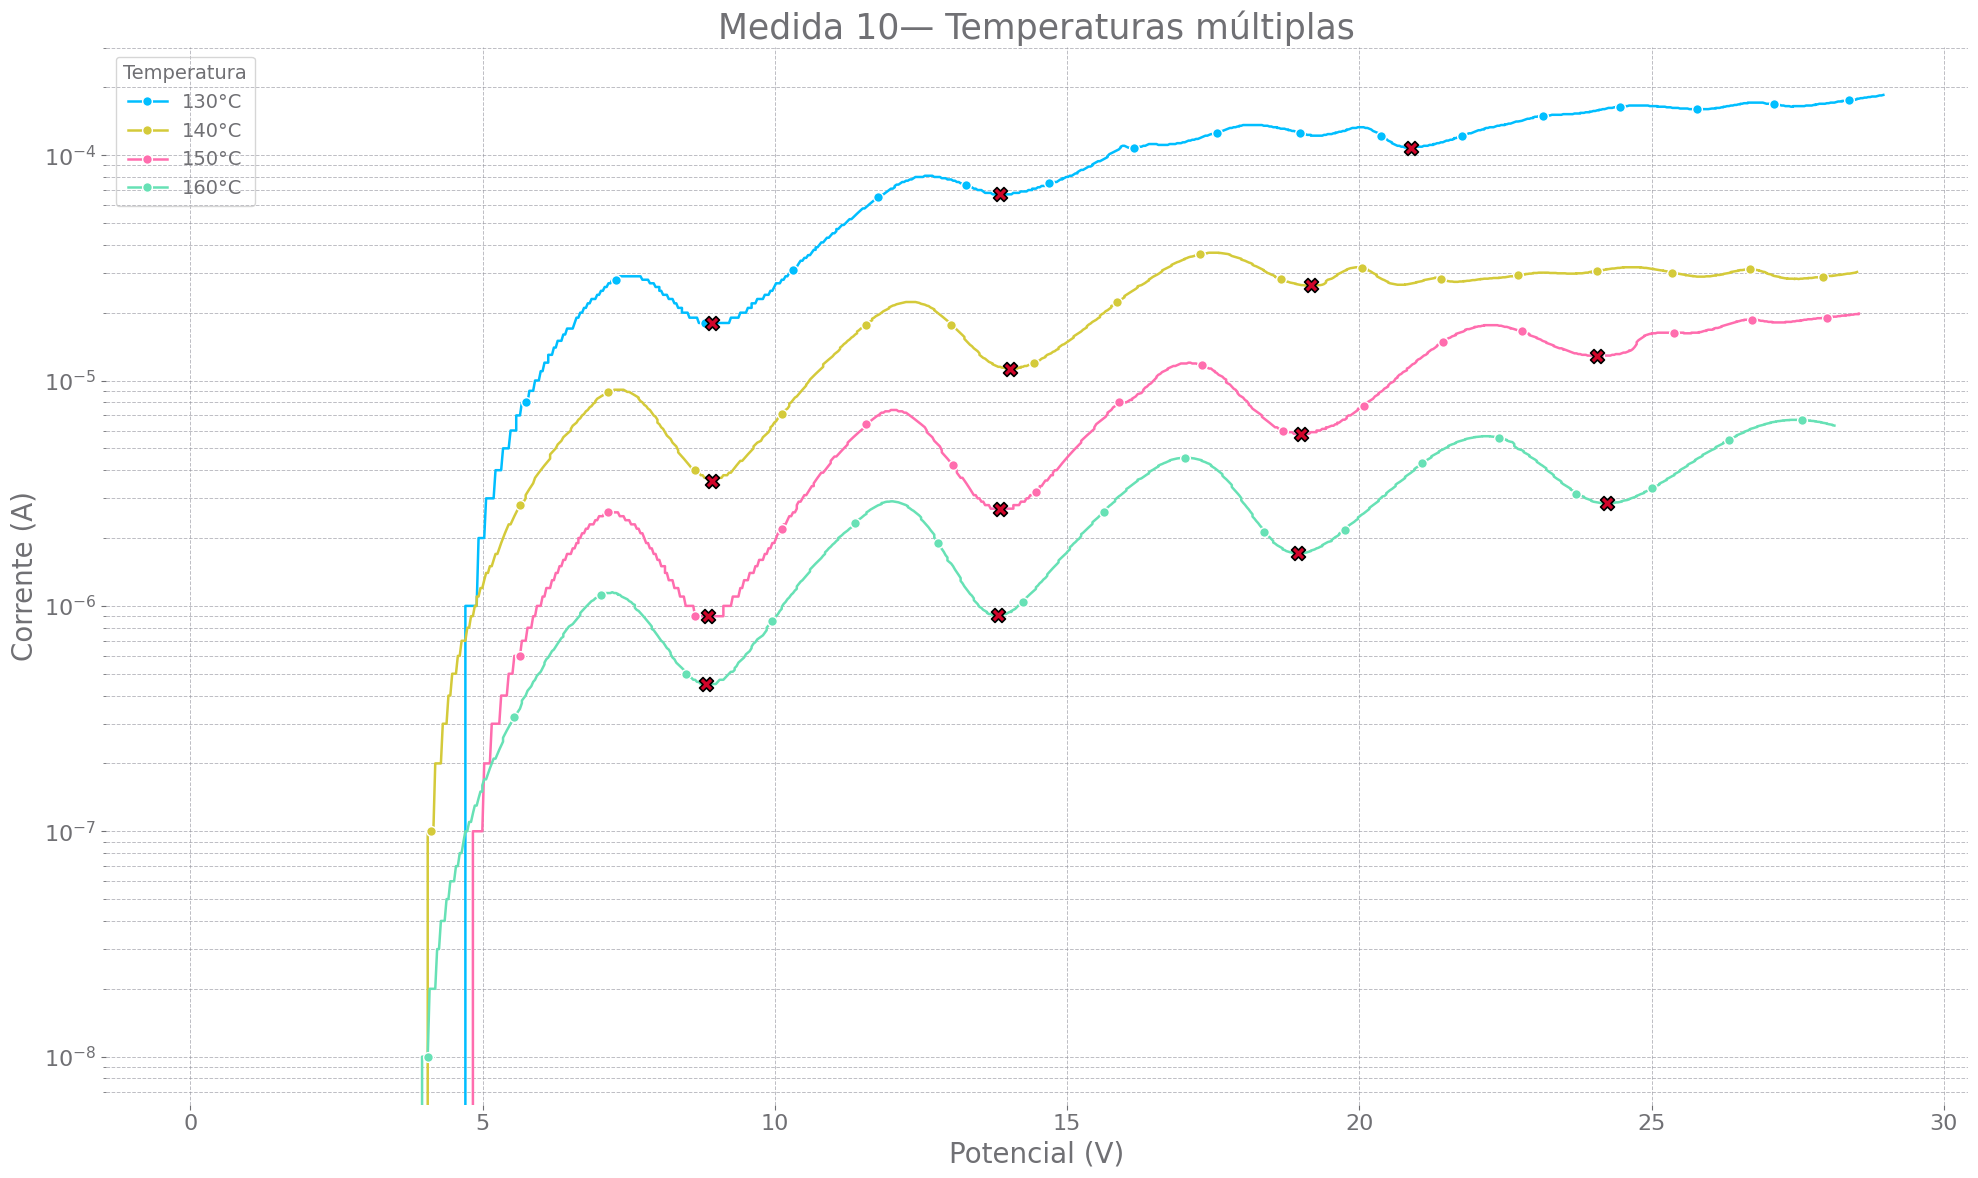

In [79]:
plot_multiplas_temperaturas(
    pasta_dados="Dados experimentais 23.10.2025 (Com fator de escala)/",
    pasta_excel="/home/joliveira/Documents/franck-hertz/",
    medida=10,
    temperaturas=(130, 140, 150, 160),
    log=True,
    mostrar_marcadores=True
)
